In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [2]:
df = pd.read_csv('data/raw/reviews.csv')

def get_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment_label'] = df['rating'].apply(get_sentiment)
print(f"Total reviews: {len(df)}")
df.head()

Total reviews: 1000


,id,review,rating,date,bank,source,sentiment_label
0,f5202b8d-cbed-4441-8c24-64d67859f06d,trash,1.0,2026-05-19,Commercial Bank of Ethiopia,Google Play,negative
1,01e4b090-3bb0-4252-8901-a5d4faf63ced,poor app,1.0,2026-05-19,Commercial Bank of Ethiopia,Google Play,negative
2,2caf219d-1b95-49a2-b092-bc8f12e6bd8c,Nice,5.0,2026-05-19,Commercial Bank of Ethiopia,Google Play,positive
3,d3cbb984-05a4-464e-a69f-3afa37873f0d,nice vv,5.0,2026-05-19,Commercial Bank of Ethiopia,Google Play,positive
4,340b454f-c54a-43b5-8a0f-87fb2639f6c1,እጅግ በጣም አሪፍ አፕ ነው። ነገር ግን የስልክ ቀፎ በቀየርኩ ቁጥር አን...,5.0,2026-05-19,Commercial Bank of Ethiopia,Google Play,positive


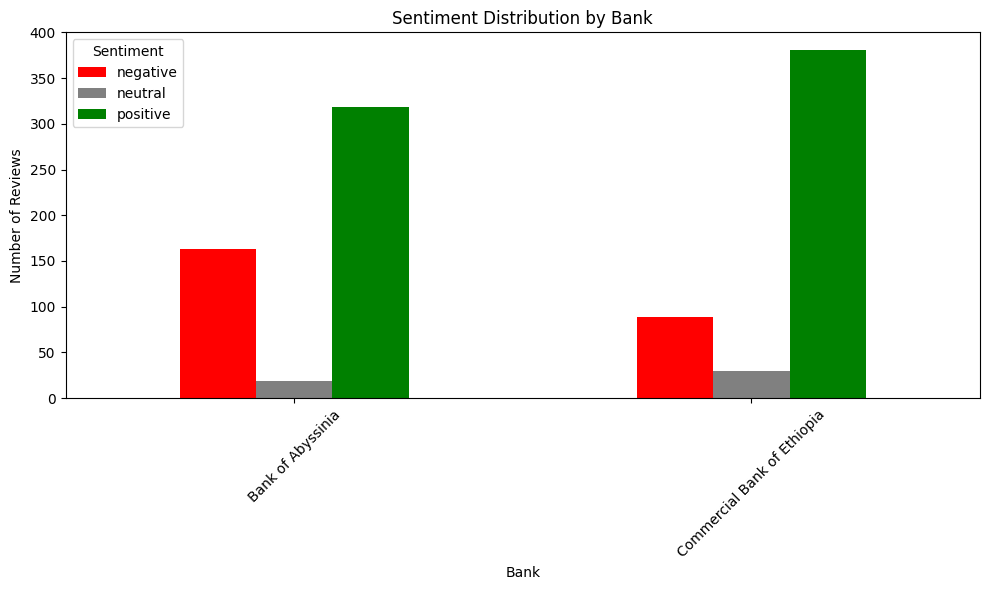

In [3]:
plt.figure(figsize=(10, 6))
df.groupby(['bank', 'sentiment_label']).size().unstack(fill_value=0).plot(
    kind='bar',
    color=['red', 'gray', 'green'],
    ax=plt.gca()
)
plt.title('Sentiment Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

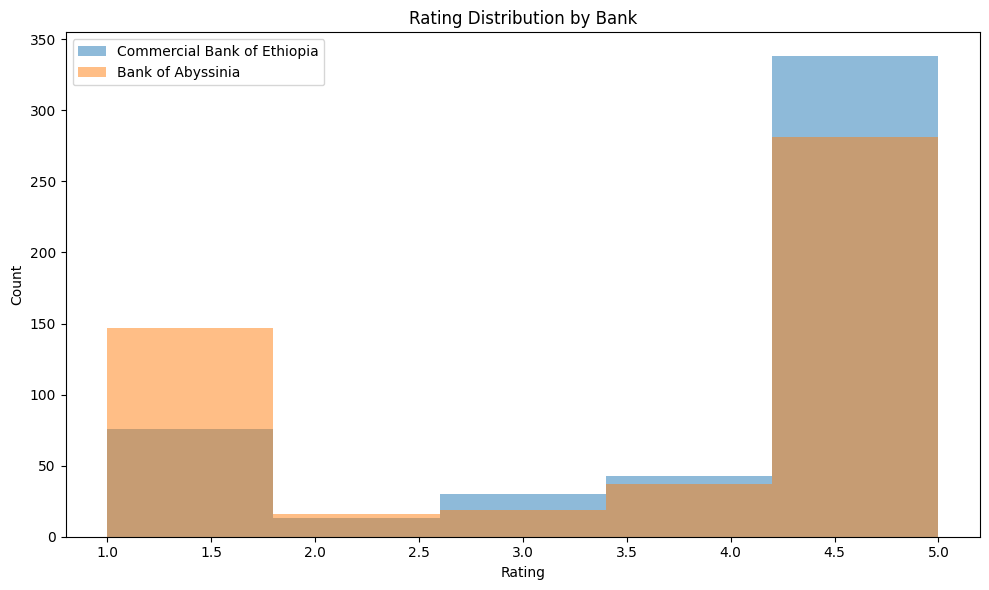

In [4]:
plt.figure(figsize=(10, 6))
for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank]
    plt.hist(bank_df['rating'], alpha=0.5, label=bank, bins=5)
plt.title('Rating Distribution by Bank')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

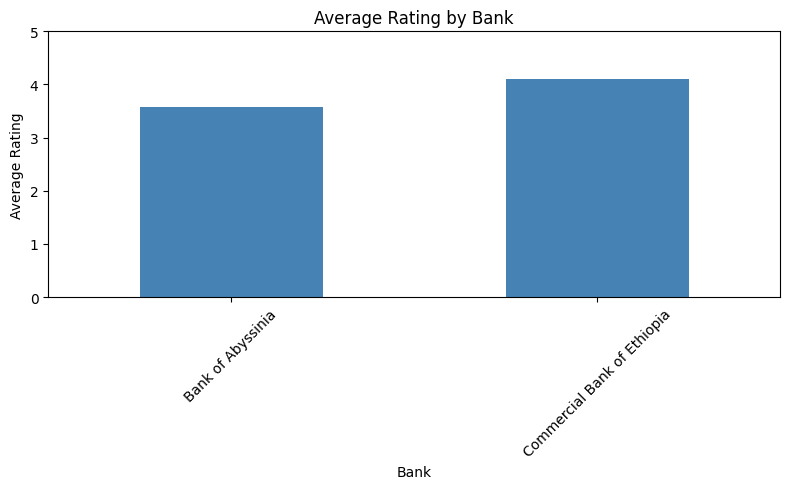

bank
Bank of Abyssinia              3.578
Commercial Bank of Ethiopia    4.108
Name: rating, dtype: float64


In [5]:
avg_rating = df.groupby('bank')['rating'].mean()
plt.figure(figsize=(8, 5))
avg_rating.plot(kind='bar', color='steelblue')
plt.title('Average Rating by Bank')
plt.xlabel('Bank')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()
print(avg_rating)

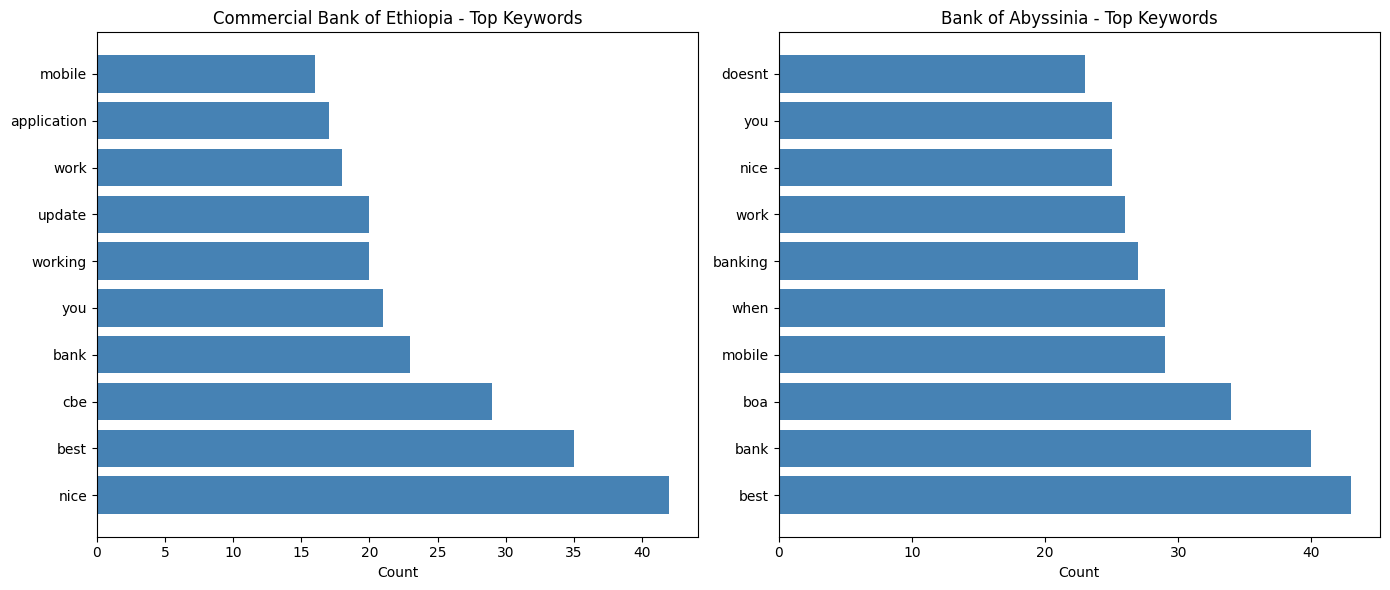

In [6]:
def get_keywords(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    words = text.split()
    stopwords = ['the','a','an','is','it','in','on','and','or','to','i','my','me','this','that','was','for','of','with','have','has','be','are','not','but','app','good','very','its']
    return [w for w in words if w not in stopwords and len(w) > 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, bank in enumerate(df['bank'].unique()):
    bank_reviews = df[df['bank'] == bank]['review']
    all_words = []
    for review in bank_reviews:
        all_words.extend(get_keywords(review))
    top_words = Counter(all_words).most_common(10)
    words = [w[0] for w in top_words]
    counts = [w[1] for w in top_words]
    axes[idx].barh(words, counts, color='steelblue')
    axes[idx].set_title(f'{bank} - Top Keywords')
    axes[idx].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [7]:
print("=" * 50)
print("INSIGHTS & RECOMMENDATIONS")
print("=" * 50)

for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank]
    avg = bank_df['rating'].mean()
    positive = len(bank_df[bank_df['sentiment_label'] == 'positive'])
    negative = len(bank_df[bank_df['sentiment_label'] == 'negative'])
    
    print(f"\n{bank}:")
    print(f"  Average Rating: {avg:.2f} ⭐")
    print(f"  Positive reviews: {positive}")
    print(f"  Negative reviews: {negative}")
    
    if avg >= 4:
        print(f"  ✅ Driver: Users are satisfied overall")
    else:
        print(f"  ❌ Pain point: Low average rating needs improvement")

INSIGHTS & RECOMMENDATIONS

Commercial Bank of Ethiopia:
  Average Rating: 4.11 ⭐
  Positive reviews: 381
  Negative reviews: 89
  ✅ Driver: Users are satisfied overall

Bank of Abyssinia:
  Average Rating: 3.58 ⭐
  Positive reviews: 318
  Negative reviews: 163
  ❌ Pain point: Low average rating needs improvement
